# Campaign for selling personal loans

This case is about a bank (Thera Bank) which has a growing customer base. Majority of these customers are liability customers (depositors) with varying size of deposits. The number of customers who are also borrowers (asset customers) is quite small, and the bank is interested in expanding this base rapidly to bring in more loan business and in the process, earn more through the interest on loans. In particular, the management wants to explore ways of converting its liability customers to personal loan customers (while retaining them as depositors). A campaign that the bank ran last year for liability customers showed a healthy conversion rate of over 9% success. This has encouraged the retail marketing department to devise campaigns with better target marketing to increase the success ratio with minimal budget.

The department wants to build a model that will help them identify the potential customers who have higher probability of purchasing the loan. This will increase the success ratio while at the same time reduce the cost of the campaign.

The file Bank_Personal_Loan_Modelling.csvView in a new window  contains data on 5000 customers. The data include customer demographic information (age, income, etc.), the customer's relationship with the bank (mortgage, securities account, etc.), and the customer response to the last personal loan campaign (Personal Loan). Among these 5000 customers, only 480 (= 9.6%) accepted the personal loan that was offered to them in the earlier campaign.


# Read the column description and ensure you understand each attribute well  (5 points)

In [1]:
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline 

import seaborn as sns
import matplotlib.pyplot as plt   
import pandas as pd
import numpy as np


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB, BernoulliNB, MultinomialNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import GridSearchCV

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc, roc_curve
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import LabelEncoder
from scipy.stats import chisquare,chi2_contingency

## Variance Inflation Factor (VIF) for Multi-Collinearity Check
from patsy import dmatrices
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
cust_data = pd.read_csv("Bank_Personal_Loan_Modelling.csv", index_col=0)
print ("Bank Customer Data size: ", cust_data.shape)
cust_data.head(10)

Bank Customer Data size:  (5000, 13)


,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
ID,,,,,,,,,,,,,
1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1
6,37,13,29,92121,4,0.4,2,155,0,0,0,1,0
7,53,27,72,91711,2,1.5,2,0,0,0,0,1,0
8,50,24,22,93943,1,0.3,3,0,0,0,0,0,1
9,35,10,81,90089,3,0.6,2,104,0,0,0,1,0


In [3]:
cust_data.shape

(5000, 13)

In [4]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


In [5]:
#All 13 variables have 5000 counts of data. Hence no data  needs to be dropped.

In [6]:
cust_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


In [7]:
cust_data.columns

Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

# Study the data distribution in each attribute, share your findings. (5 points)
# Get the target column distribution. Your comments (5 points)

In [8]:
#The customer data with the bank has the below information

#ID: An ID column to index the data and also to identify the customer as a customer ID. 

#Age: Current completed Age of the customer. Minimum customer age is 23yrs and maximum age is 67

#Experience:
#Experience level of the customer. This value ranges from -3 to 43 years. 
#The negative number could be an incorrect number.B
#But upon analysing, it is understood that only <30yr aged customers have negative numbers.
#Hence it is a correct data in which it indicates that the experience of the customer is yet to start in so many years.
#Example, if the number is -3, the customer will be starting the job after 3 years from now.

#Income: 
#Income of the customer in lakhs or thousands or some unit of local currency per annum or per month or per week (any standard period)
#Let's assume that it is 1000s in local currency (say USD) value per annum

#ZIP Code: Zip code of the area of the customer's address. This is a label of the area.

#Family: No of family members of the customer. This ranges from 1-4 members

#CCAvg: (Value Range: 0-10) Avg. spending on credit cards per month ($ or local currency in thousands)

#Education: A labeled categorised data of the customer's education level. (could be graduate, post graduate, school, etc)

#Mortgage (Value Range: 0(none) or 75-635): Value of house mortgage if any. (Assume in thousands of $ or local currency)

#Personal Loan (0 or 1): Whether the customer accepted the personal loan offered in the last campaign

#Securities Account (0 or 1): Whether the customer has a securities/ brokerage account with the bank (an investor/trader).
#Securities account holds financial assets such as securities on behalf of an investor with a bank, broker or custodian. 

#CD Account (0 or 1) Does the customer have a certificate of deposit (CD) account with the bank?

#Online (0 or 1) Does the customer use internet banking facilities?

#CreditCard (0 or 1) Does the customer use a credit card issued by Thera Bank?

In [9]:
# Continuous: Age, Experience, Income, FamilyMembers, CCAvg, Mortgage 
cont_vars= ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage'] 

# Categorical: ZIP Code, Education, Securities Account, CD Account, Online, CreditCard
cat_vars = ['ZIP Code', 'Education', 'Securities Account', 'CD Account', 'Online', 'CreditCard']

In [10]:
# lets check the variance of continuous variables. If it is > 1
cust_data[cont_vars].var()

Age             131.404166
Experience      131.513962
Income         2119.104235
Family            1.317130
CCAvg             3.054312
Mortgage      10345.697538
dtype: float64

In [11]:
cust_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


In [12]:
cust_data.median()

Age                      45.0
Experience               20.0
Income                   64.0
ZIP Code              93437.0
Family                    2.0
CCAvg                     1.5
Education                 2.0
Mortgage                  0.0
Personal Loan             0.0
Securities Account        0.0
CD Account                0.0
Online                    1.0
CreditCard                0.0
dtype: float64

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

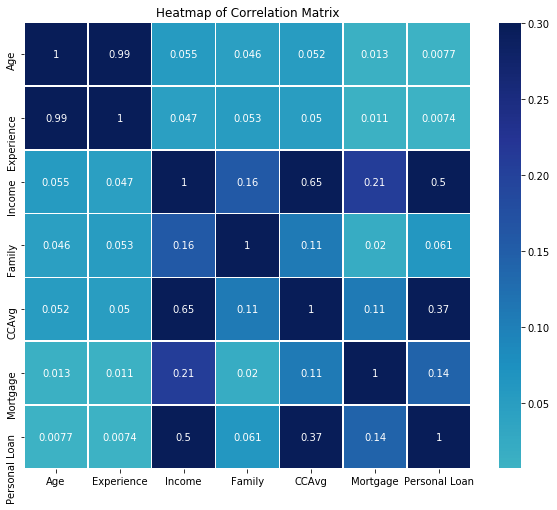

In [13]:
#Correlation among continuous variables
corr_matrix = cust_data[cont_vars + ['Personal Loan']].corr().abs()
plt.figure(figsize = (10,10))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, cmap="YlGnBu", vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

Text(0.5, 1.0, 'Heatmap of Correlation Matrix')

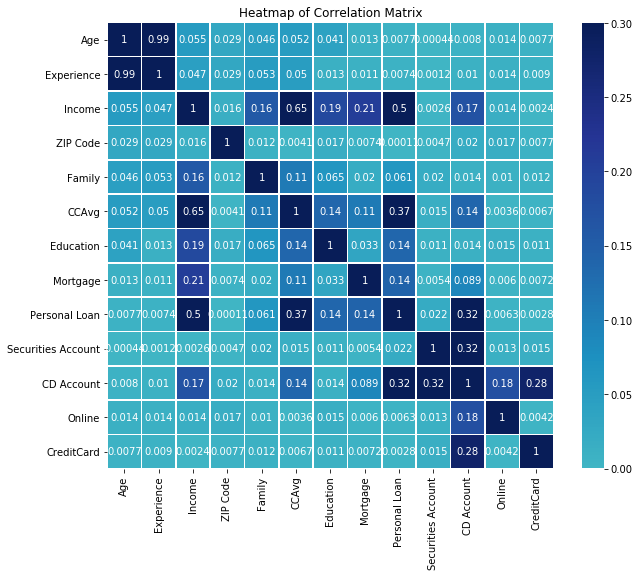

In [14]:
corr_matrix = cust_data.corr().abs()
plt.figure(figsize = (10,10))
cmap = sns.diverging_palette(220, 10, as_cmap=True)
sns.heatmap(corr_matrix,annot=True, xticklabels=corr_matrix.columns.values, yticklabels=corr_matrix.columns.values, cmap="YlGnBu", vmax=.3, center=0, square=True, linewidths=.5, cbar_kws={"shrink": .82})
plt.title('Heatmap of Correlation Matrix')

In [15]:
# Lets do chisquare on categorical variables
# check the proportions
for cat in cat_vars:
    print ("VAR:", cat, " : ", chisquare(cust_data[cat].value_counts()))

VAR: ZIP Code  :  Power_divergenceResult(statistic=9002.3412, pvalue=0.0)
VAR: Education  :  Power_divergenceResult(statistic=168.7756, pvalue=2.2430766788076054e-37)
VAR: Securities Account  :  Power_divergenceResult(statistic=3129.9872, pvalue=0.0)
VAR: CD Account  :  Power_divergenceResult(statistic=3864.9632, pvalue=0.0)
VAR: Online  :  Power_divergenceResult(statistic=187.4048, pvalue=1.1717289541793369e-42)
VAR: CreditCard  :  Power_divergenceResult(statistic=848.72, pvalue=1.3798799241981823e-186)


In [16]:
# p < 0.05 : All cat variables have poor proportions.

In [17]:
for outc in cat_vars:
    for inc in cat_vars:
        if outc != inc:
            cont = pd.crosstab(cust_data[outc], cust_data[inc])
            if chi2_contingency(cont)[1] < 0.05:
                print("VAR:", outc, ' vs ', inc, ' : ', chi2_contingency(cont)[1], '   - Dependent')
            #else:
            #    print("VAR:", outc, ' vs ', inc, ' : ', chi2_contingency(cont)[1], '   - Independent')

VAR: Securities Account  vs  CD Account  :  2.3289041632628143e-110    - Dependent
VAR: CD Account  vs  Securities Account  :  2.3289041632628143e-110    - Dependent
VAR: CD Account  vs  Online  :  3.520986431502714e-35    - Dependent
VAR: CD Account  vs  CreditCard  :  7.325271343317597e-86    - Dependent
VAR: Online  vs  CD Account  :  3.520986431502714e-35    - Dependent
VAR: CreditCard  vs  CD Account  :  7.325271343317597e-86    - Dependent


In [18]:
# Lets check dependency with Personal Loan
for col in cat_vars:
    if 'Personal Loan' != col:
        cont = pd.crosstab(cust_data['Personal Loan'], cust_data[col])
        if chi2_contingency(cont)[1] < 0.05:
            print("VAR:", 'Personal Loan', ' vs ', col, ' : ', chi2_contingency(cont)[1], '   - Dependent')
        #else:
        #    print("VAR:", 'Personal Loan', ' vs ', col, ' : ', chi2_contingency(cont)[1], '   - Independent')

VAR: Personal Loan  vs  Education  :  6.991473868665428e-25    - Dependent
VAR: Personal Loan  vs  CD Account  :  7.398297503329848e-110    - Dependent


In [19]:
corr_matrix['Personal Loan'].sort_values(ascending=False)

Personal Loan         1.000000
Income                0.502462
CCAvg                 0.366889
CD Account            0.316355
Mortgage              0.142095
Education             0.136722
Family                0.061367
Securities Account    0.021954
Age                   0.007726
Experience            0.007413
Online                0.006278
CreditCard            0.002802
ZIP Code              0.000107
Name: Personal Loan, dtype: float64

In [20]:
cust_data['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

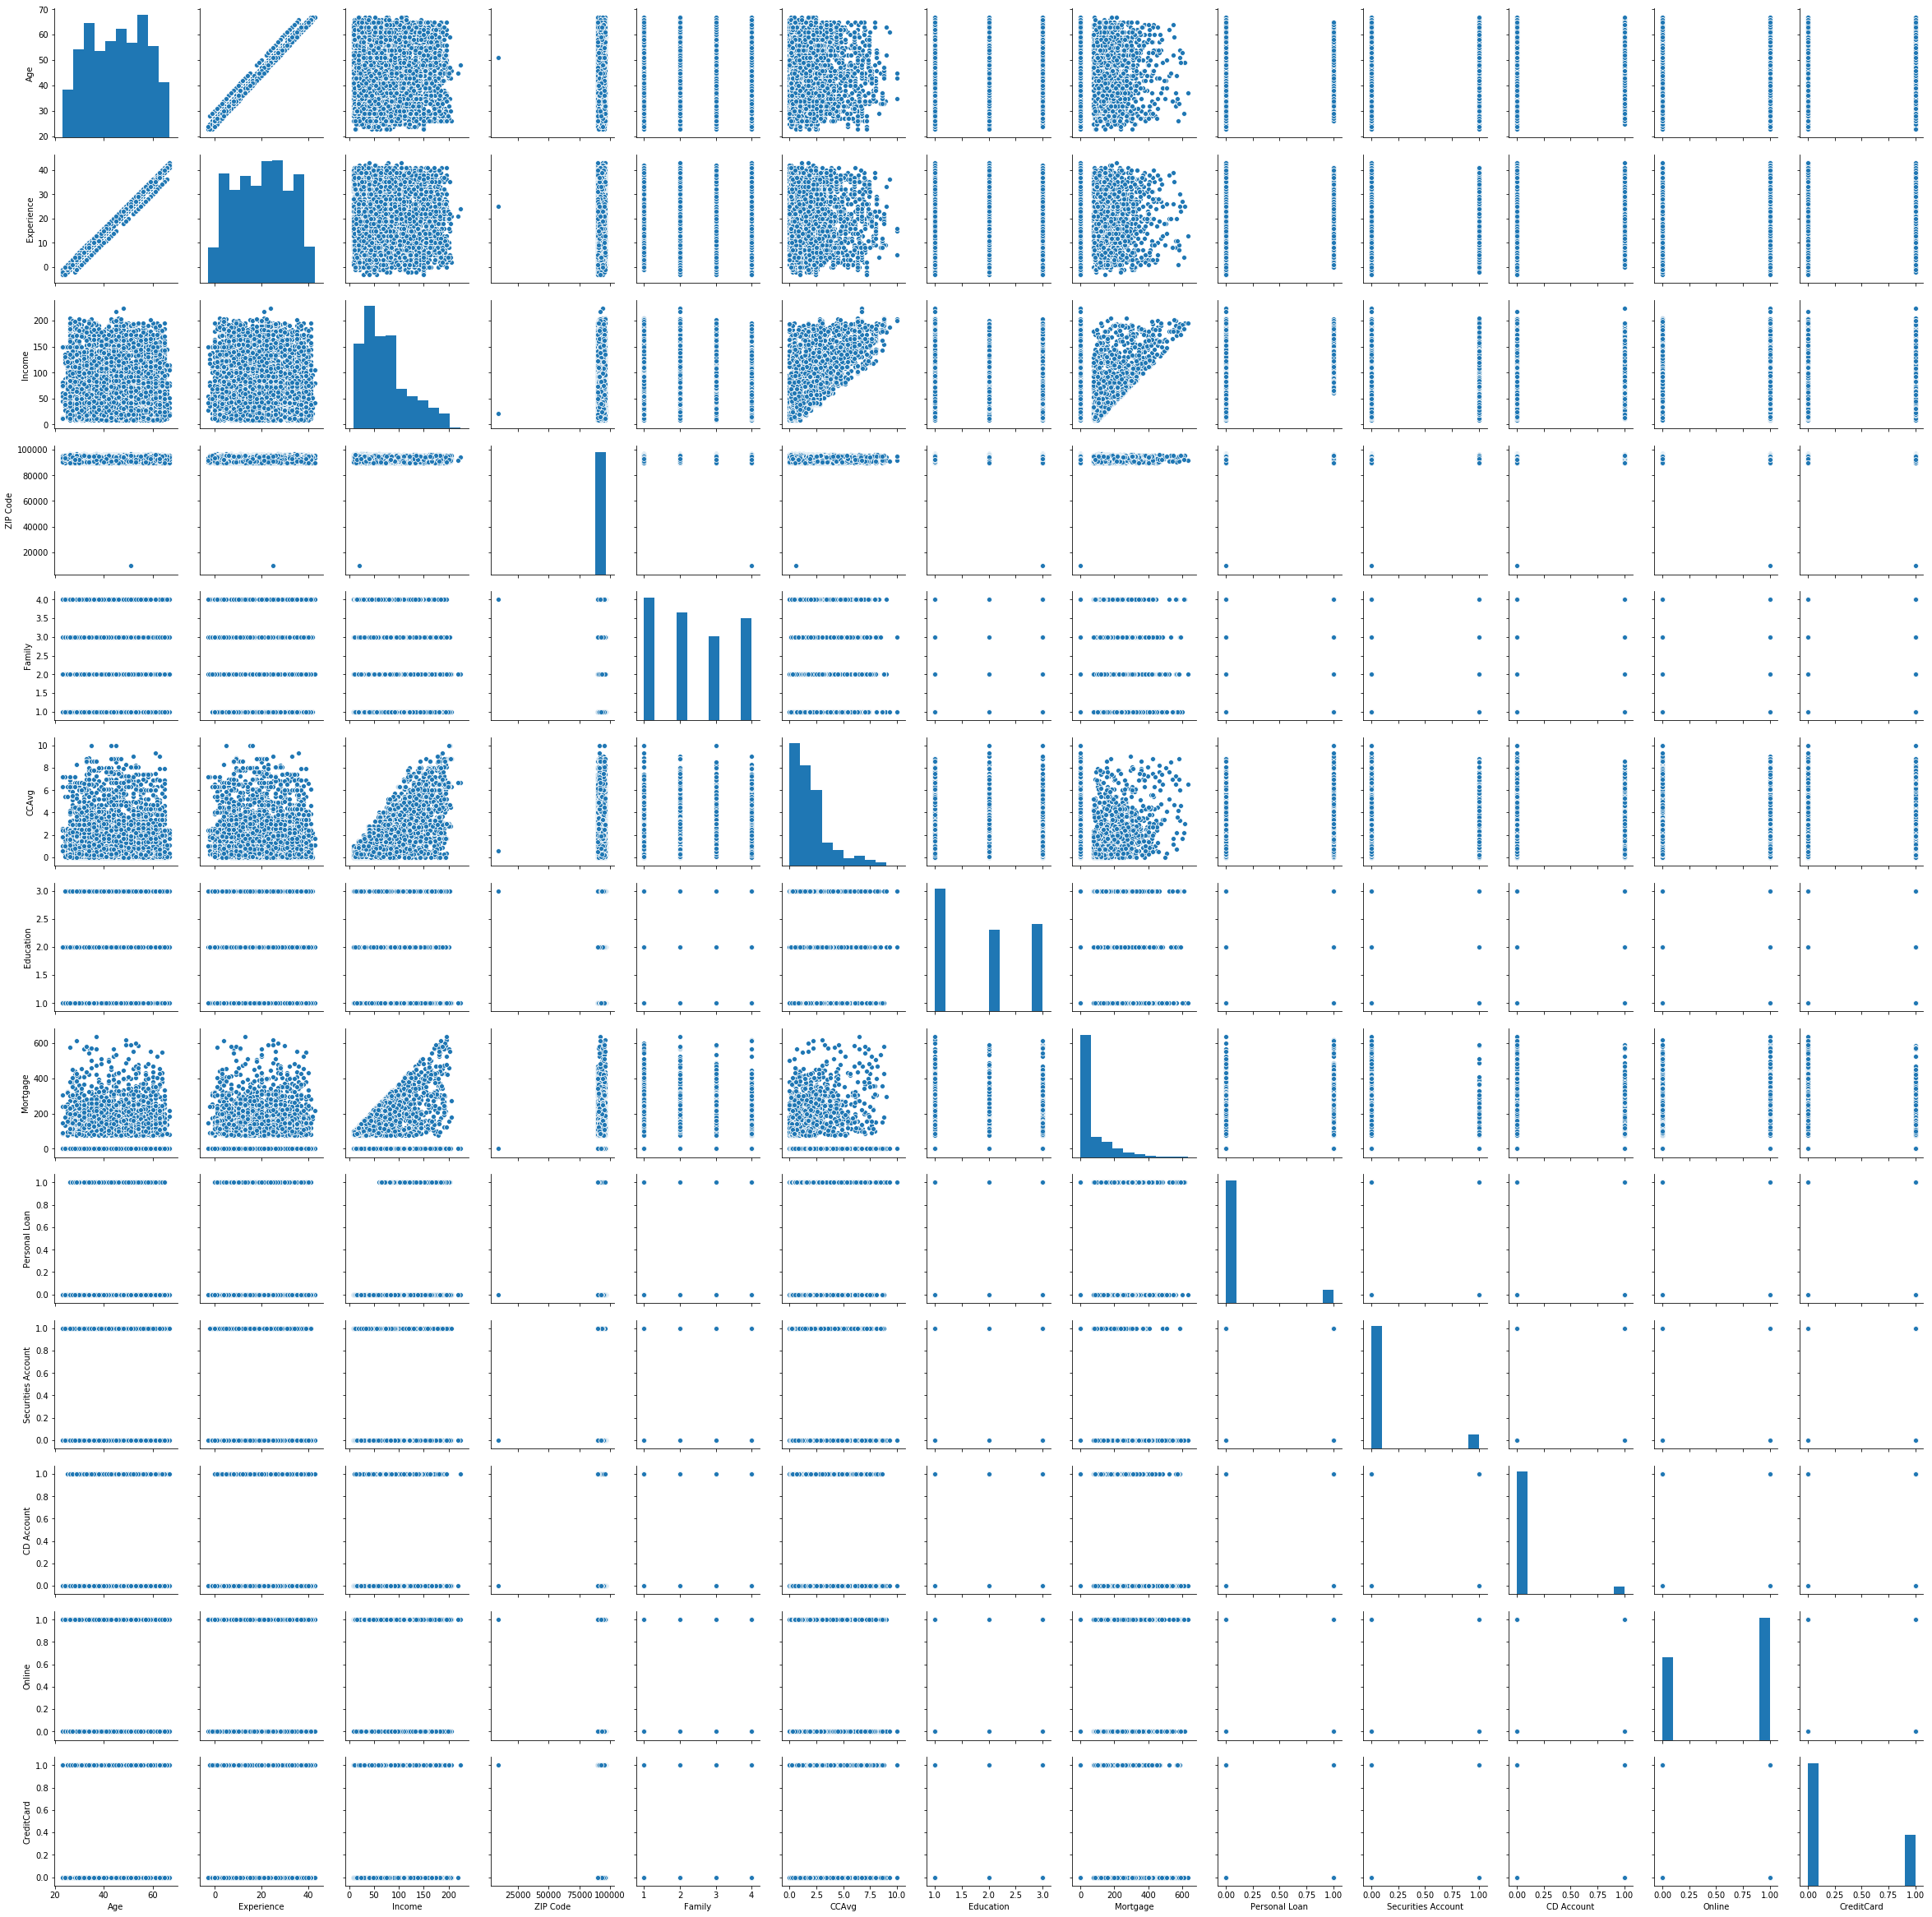

In [21]:
# Have look at pair plot.
sns.pairplot(cust_data)

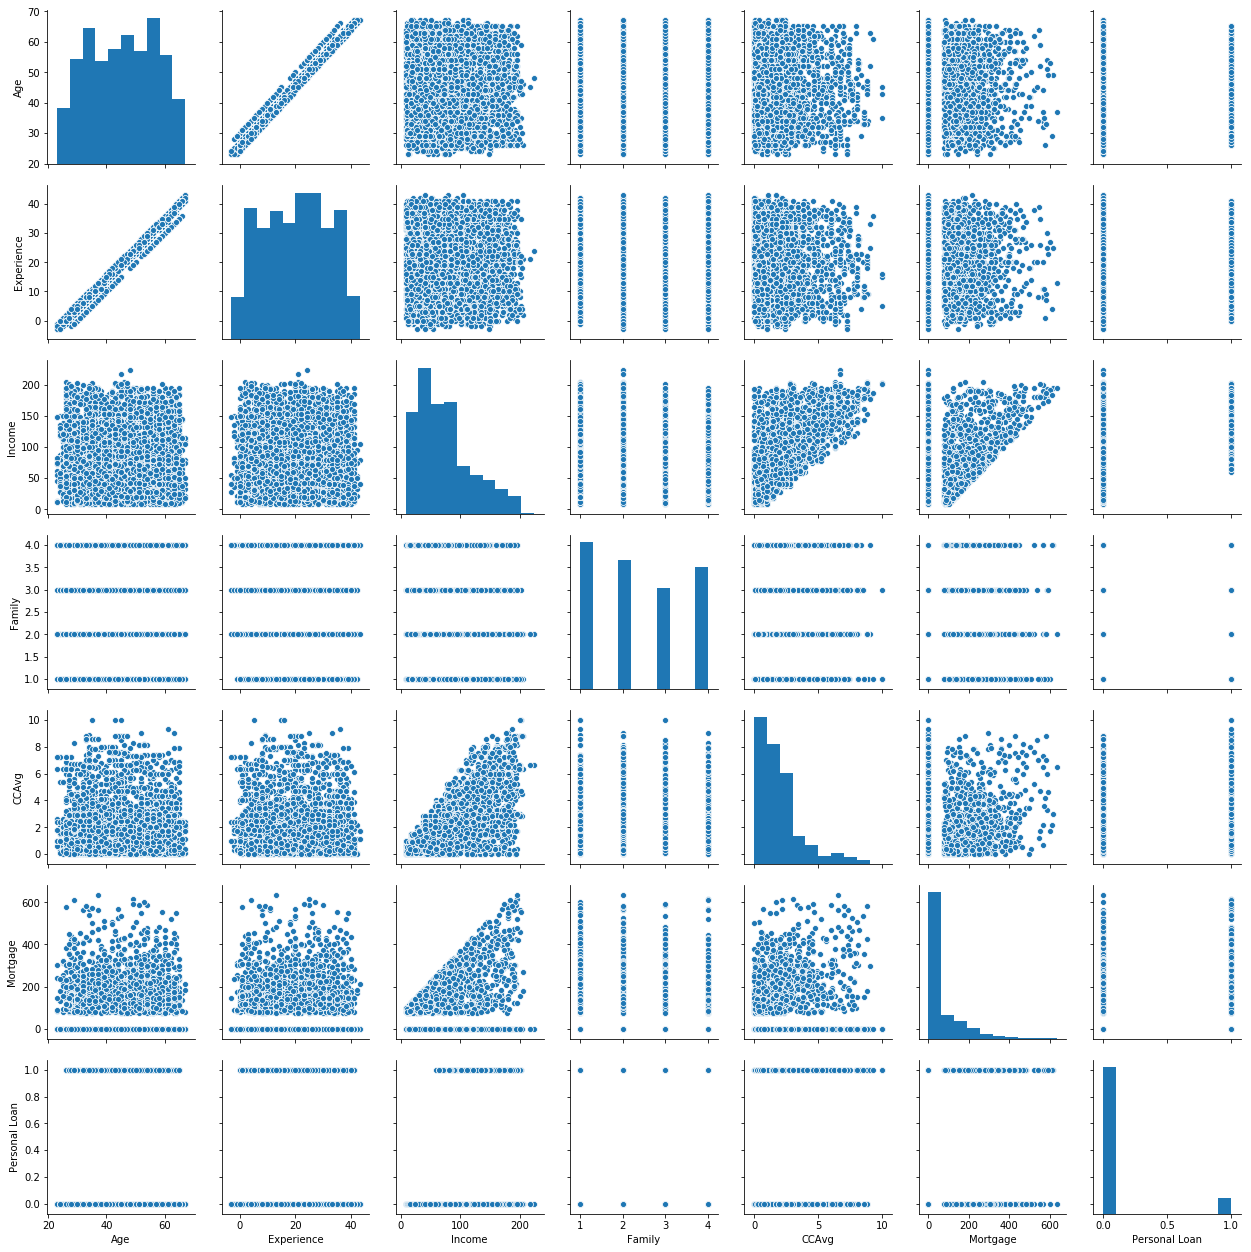

In [22]:
#Pair plot only for continuous variables
plot_cols = ['Age', 'Experience', 'Income', 'Family', 'CCAvg', 'Mortgage', 'Personal Loan'] 
sns.pairplot(cust_data[plot_cols])

Personal Loan
0    [[AxesSubplot(0.125,0.725918;0.215278x0.154082...
1    [[AxesSubplot(0.125,0.725918;0.215278x0.154082...
dtype: object

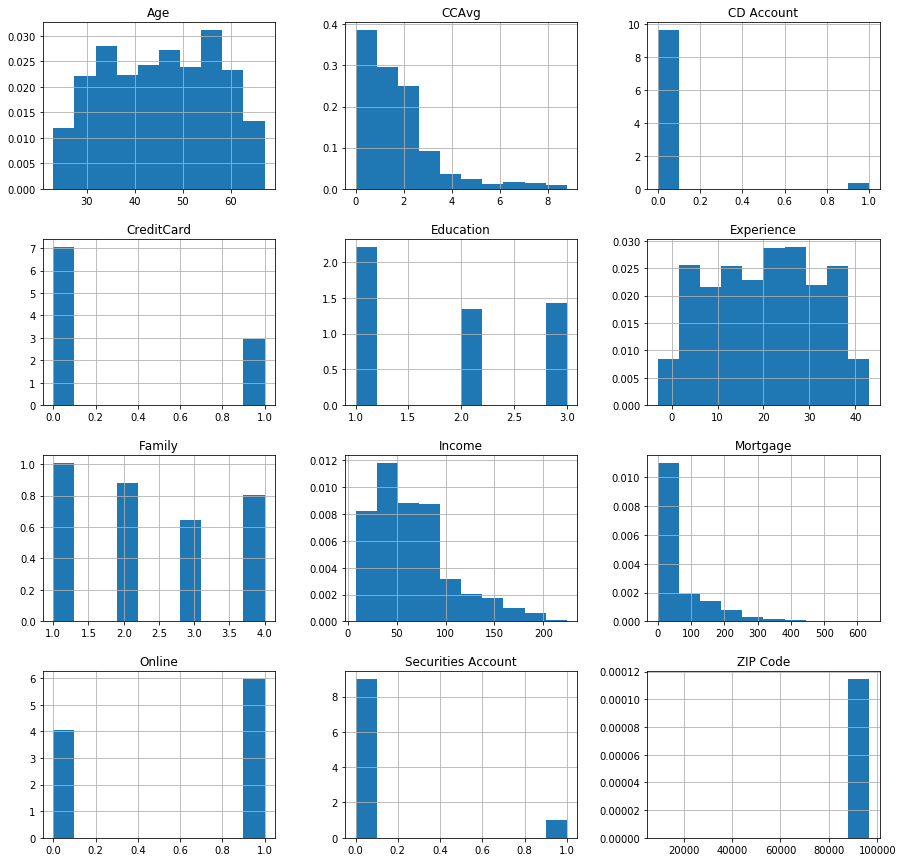

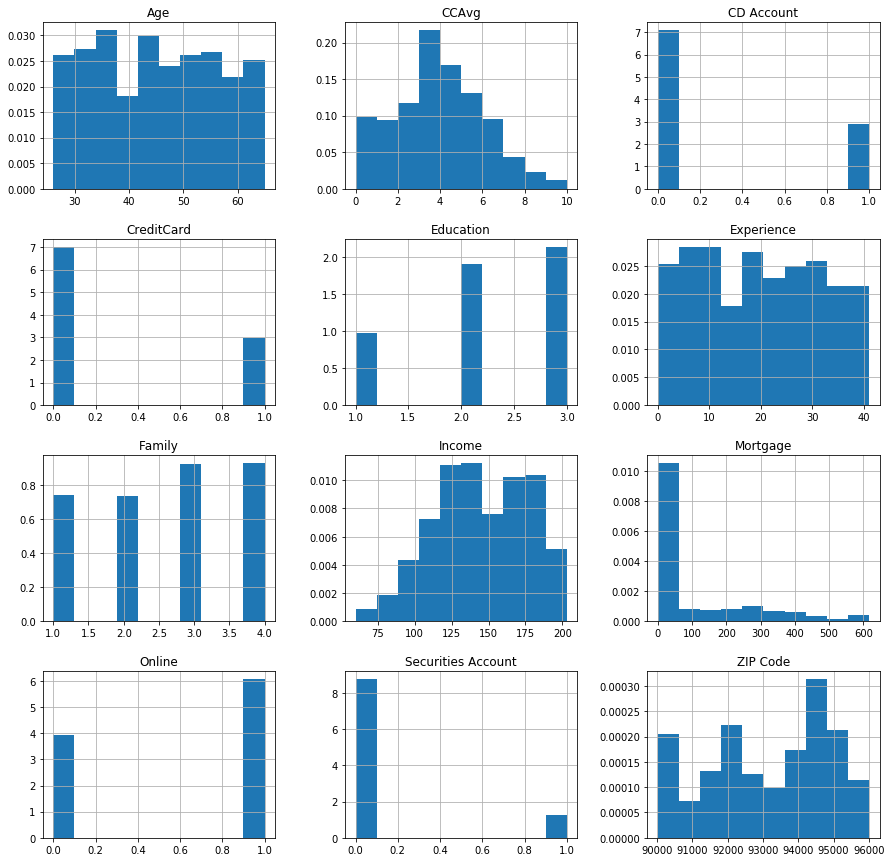

In [23]:
cust_data.groupby('Personal Loan').hist(density=True, figsize=(15, 15))

In [24]:
# Analysis:

#correlation among variables
# Experience & Age are very strongly correlated. One of them could be dropped to avoid strong influence
# Income & CCAVg are strongly correlated. One of them could be dropped to avoid strong influence
# Income/ CCAvg are highly related to Personal loan
# Securities Account  and  CD Account are dependent on each other
# CD Account  and  Online are dependent on each other
# CreditCard  and  CD Account are dependent on each other

#Continuous variables relationship with personal loan:
# ----------------------------------------------------
#  * Dependent continuous varables are Income and CCAvg.  Mortage Loan also has a good correlation with Personal loan. 
#  * Other continuous varableslike  Experience, Age and Family Members have low effect on personal loan


#Categorical variables relationship with personal loan:
# ----------------------------------------------------
#  * Chi Conclusion:
#  * Dependent categorical varables are CD Account and Education
#  * CD Account is better representative among (Securities Account, CD Account, Online and CreditCard)
#  * Zipcode is not correlated to any data at all. It can be ignored.


#Conclusion:
# Personal Loan : Is dependent on Income, CCavg and CD Account. Education and Mortage Loan also has a good correlation with Personal loan.

In [25]:
# Pair plot observations wrt personal loan.

# Continuous Variables
# ---------------------
# Age: Normal distribution
# Experience: Normal distribution
# Income: Right skewed
# CCAvg : Right skewed. Not a normal distribution.
#         Could consider log function to make it proper distribution.
# Mortgage : The median is zero. This variable has very high values and lots of zeros. 
#            Could consider log function to bring big values close to zero. 

# Categorical Variables
# ---------------------
#  Dependent categorical varables are CD Account and Education

# From plots, it is observed that, CCAvg, Mortage Loans, Income and age/ experience has effect on personal loan
# But correlation provides no effect of age/ experience on personal loan

In [26]:
cust_data['ZIP Code'] = LabelEncoder().fit_transform(cust_data['ZIP Code'])
cust_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,239.664400,130.850803,0.0,131.0,254.0,352.0,466.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


# Split the data into training and test set in the ratio of 70:30 respectively ( 5 points) 

In [27]:
X = cust_data.drop("Personal Loan", axis=1)
y = cust_data["Personal Loan"]
test_size = 0.3 # taking 70:30 training and test set
seed = 7
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
print("Train Count:", X_train.shape)
print("Test Count:", X_test.shape)

Train Count: (3500, 12)
Test Count: (1500, 12)


# Use different classification models (Logistic, K-NN and Naïve Bayes) to predict the likelihood of a liability customer buying personal loans (25 points)

# Print the confusion matrix for all the above models (10 points) 

In [28]:
def modelFitPredictPerformanceAnalysis(model):
       
    test_size = 0.3 # taking 70:30 training and test set
    seed = 7
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)
    
    model.fit(X_train, y_train)
    
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainConfMatrix = metrics.confusion_matrix(y_train, trainPreds)
    trainCrossVal = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy').mean()
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score, trainConfMatrix, trainCrossVal]
    
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testConfMatrix = metrics.confusion_matrix(y_test, testPreds)
    testCrossVal = cross_val_score(model, X_test, y_test, cv=10, scoring='accuracy').mean()
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score, testConfMatrix, testCrossVal]
    
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score", "confusion matrix", "Cross_val_score"])
    
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    
    return resultsDf.round(2)

In [29]:
#Removing some of the highly correlated dependent variables

#Note the below

#correlation among variables
# Experience & Age are very strongly correlated. One of them could be dropped to avoid strong influence
# Income & CCAVg are strongly correlated. One of them could be dropped to avoid strong influence
# Income/ CCAvg are also highly related to Personal loan
# Securities Account  and  CD Account are dependent on each other
# CD Account  and  Online are are dependent on each other
# CreditCard  and  CD Account are dependent on each other

In [30]:
def modelAnalysisAfterRemoveVar(model):
    X = cust_data.drop(["Personal Loan", "Age", "CCAvg", "CD Account"], axis=1).values
    y = cust_data["Personal Loan"]

    test_size = 0.3 # taking 70:30 training and test set
    seed = 7
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

    model.fit(X_train, y_train)
    
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainConfMatrix = metrics.confusion_matrix(y_train, trainPreds)
    trainCrossVal = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy').mean()
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score, trainConfMatrix, trainCrossVal]
    
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testConfMatrix = metrics.confusion_matrix(y_test, testPreds)
    testCrossVal = cross_val_score(model, X_test, y_test, cv=10, scoring='accuracy').mean()
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score, testConfMatrix, testCrossVal]
    
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score", "confusion matrix", "Cross_val_score"])
    
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    
    return resultsDf.round(2)

In [31]:
def modelAnalysis(model):
    X = cust_data.drop(["Personal Loan", "Age", "CCAvg", "CD Account", "ZIP Code"], axis=1).values
    y = cust_data["Personal Loan"]

    test_size = 0.3 # taking 70:30 training and test set
    seed = 7
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=test_size, random_state=seed)

    model.fit(X_train, y_train)
    
    ### Unoptimized probability threshold based performance numbers
    # Train accuracy numbers
    trainPreds = model.predict(X_train)
    trainAccuracy = accuracy_score(y_train, trainPreds)
    trainRecall = recall_score(y_train, trainPreds)
    trainPrecision = precision_score(y_train, trainPreds)
    trainF1score = f1_score(y_train, trainPreds)
    trainConfMatrix = metrics.confusion_matrix(y_train, trainPreds)
    trainCrossVal = cross_val_score(model, X_train, y_train, cv=10, scoring='accuracy').mean()
    trainResults=[X_train.shape[0], trainAccuracy, trainRecall, trainPrecision, trainF1score, trainConfMatrix, trainCrossVal]
    
    # Test accuracy numbers
    testPreds = model.predict(X_test)
    testAccuracy = accuracy_score(y_test, testPreds)
    testRecall = recall_score(y_test, testPreds)
    testPrecision = precision_score(y_test, testPreds)
    testF1score = f1_score(y_test, testPreds)
    testConfMatrix = metrics.confusion_matrix(y_test, testPreds)
    testCrossVal = cross_val_score(model, X_test, y_test, cv=10, scoring='accuracy').mean()
    testResults=[X_test.shape[0], testAccuracy, testRecall, testPrecision, testF1score, testConfMatrix, testCrossVal]
    
    resultsDf = pd.DataFrame( index=["dataSize", "accuracy", "recall", "precision", "f1_score", "confusion matrix", "Cross_val_score"])
    
    # Concatenate Train and Test results to resultsDf
    resultsDf['unOptimalTrainResults'] = trainResults
    resultsDf['unOptimalTestResults'] = testResults
    
    return resultsDf.round(2)

In [32]:
model = LogisticRegression()
print("LogisticRegression Model Analysis:")
print("")
print(modelFitPredictPerformanceAnalysis(model))
print("")
print("")
print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("")
print(modelAnalysisAfterRemoveVar(model))
print("")
print("")
print("Remove Zip Code too. Drop this column")
print("")
print(modelAnalysis(model))

LogisticRegression Model Analysis:

                     unOptimalTrainResults    unOptimalTestResults
dataSize                              3500                    1500
accuracy                          0.947714                   0.954
recall                            0.599415                0.637681
precision                         0.816733                 0.82243
f1_score                            0.6914                0.718367
confusion matrix  [[3112, 46], [137, 205]]  [[1343, 19], [50, 88]]
Cross_val_score                   0.945998                0.951999


Remove Age, CCAvg and CD Account from variables list. Drop these columns

                     unOptimalTrainResults    unOptimalTestResults
dataSize                              3500                    1500
accuracy                          0.939714                    0.95
recall                            0.526316                0.557971
precision                         0.786026                0.846154
f1_score         

In [33]:
#Observations
#Logistic Regression 
#With high accuracy, precision and decent recall values, the classifier is extremely accurate
#It might also classify significant number of difficult instances well

#After removing  highly correlated data, Logistic regression has a slight reduction in recall scores but still good
#Precision score has improved

#Removing not useful data ZIP Code, has less effect on  Logistic regression model

In [34]:
model = GaussianNB()
print("GaussianNB Model Analysis:")
print("")
print(modelFitPredictPerformanceAnalysis(model))
print("")
print("")
print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("")
print(modelAnalysisAfterRemoveVar(model))
print("")
print("")
print("Remove Zip Code too. Drop this column")
print("")
print(modelAnalysis(model))

GaussianNB Model Analysis:

                      unOptimalTrainResults     unOptimalTestResults
dataSize                               3500                     1500
accuracy                              0.882                 0.879333
recall                              0.55848                 0.594203
precision                          0.421634                 0.396135
f1_score                           0.480503                 0.475362
confusion matrix  [[2896, 262], [151, 191]]  [[1237, 125], [56, 82]]
Cross_val_score                    0.881997                  0.89534


Remove Age, CCAvg and CD Account from variables list. Drop these columns

                      unOptimalTrainResults    unOptimalTestResults
dataSize                               3500                    1500
accuracy                           0.918571                0.928667
recall                             0.476608                0.478261
precision                          0.605948                0.653465
f1_s

In [35]:
#Observations

#GaussianNB 
#With good accuracy and moderate precision and moderate recall, the classifier is extremely accurate
#and might also not miss a significant number of instances that are difficult to classify

#After removing  highly correlated data, GaussianNB has improved accuracy, precision, F1 and Cros_val scores. 
#But recall scores reduced below 0.5 which is not good (sensitivity). 

#Removing not useful data ZIP Code, has less effect on  GaussianNB model like the logistic regression model

In [36]:
knn_classifier = KNeighborsClassifier(algorithm='brute',weights='distance')
n = list(range(1,60))
params = {'n_neighbors':n}
grid = GridSearchCV(knn_classifier,param_grid=params,scoring='accuracy',cv=10)
grid.fit(X_train,y_train)
print(grid.best_score_)
print(grid.best_params_)

0.9048571428571428
{'n_neighbors': 13}


In [37]:
model = KNeighborsClassifier(n_neighbors= 13)
print("KNeighborsClassifier Model Analysis:")
print("")
print(modelFitPredictPerformanceAnalysis(model))
print("")
print("")
print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("")
print(modelAnalysisAfterRemoveVar(model))
print("")
print("")
print("Remove Zip Code too. Drop this column")
print("")
print(modelAnalysis(model))

KNeighborsClassifier Model Analysis:

                     unOptimalTrainResults     unOptimalTestResults
dataSize                              3500                     1500
accuracy                          0.913714                 0.902667
recall                             0.30117                 0.202899
precision                         0.620482                   0.4375
f1_score                          0.405512                 0.277228
confusion matrix  [[3095, 63], [239, 103]]  [[1326, 36], [110, 28]]
Cross_val_score                   0.902288                 0.910025


Remove Age, CCAvg and CD Account from variables list. Drop these columns

                     unOptimalTrainResults     unOptimalTestResults
dataSize                              3500                     1500
accuracy                             0.916                 0.909333
recall                            0.321637                 0.253623
precision                         0.639535                 0.514706
f1

In [38]:
#Observations

#KNN
#With good accuracy and moderate precision but low recall, the classifier is extremely accurate
#But it might miss a significant number of instances that are difficult to classify.

#After removing  highly correlated data, KNN has improved accuracy, precision, recall and F1 scores. 
#But recall score is still not good (sensitivity). 

#Removing not useful data ZIP Code, has improved accuracy and precision score significantly in KNN model without affecting the sensitivity

In [39]:
#Try removing outliers, if any

#Read data again from csv file

cust_data = pd.read_csv("Bank_Personal_Loan_Modelling.csv", index_col=0)
cust_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,5000.0,45.338400,11.463166,23.0,35.0,45.0,55.0,67.0
Experience,5000.0,20.104600,11.467954,-3.0,10.0,20.0,30.0,43.0
Income,5000.0,73.774200,46.033729,8.0,39.0,64.0,98.0,224.0
ZIP Code,5000.0,93152.503000,2121.852197,9307.0,91911.0,93437.0,94608.0,96651.0
Family,5000.0,2.396400,1.147663,1.0,1.0,2.0,3.0,4.0
CCAvg,5000.0,1.937938,1.747659,0.0,0.7,1.5,2.5,10.0
Education,5000.0,1.881000,0.839869,1.0,1.0,2.0,3.0,3.0
Mortgage,5000.0,56.498800,101.713802,0.0,0.0,0.0,101.0,635.0
Personal Loan,5000.0,0.096000,0.294621,0.0,0.0,0.0,0.0,1.0
Securities Account,5000.0,0.104400,0.305809,0.0,0.0,0.0,0.0,1.0


In [40]:
# Lets drop outliers by 1.5 IQR
def get_subset_by_IQR(cust_data,column):
    q1 = cust_data[column].quantile(0.25)
    q3 = cust_data[column].quantile(0.75)
    IQR = q3 - q1
    q1 = q1 - IQR*1.5
    q3 = q3 + IQR*1.5
    iqr = (cust_data[column] > q1) & (cust_data[column] < q3)
    return cust_data.loc[iqr]

for col in cont_vars:
    before = cust_data.shape[0]
    cust_data = get_subset_by_IQR(cust_data, col)
    after = cust_data.shape[0]
    print("On", col, "column, Dropped:", (before-after), "entries")

On Age column, Dropped: 0 entries
On Experience column, Dropped: 0 entries
On Income column, Dropped: 96 entries
On Family column, Dropped: 0 entries
On CCAvg column, Dropped: 295 entries
On Mortgage column, Dropped: 251 entries


In [41]:
print(cust_data.info())

<class 'pandas.core.frame.DataFrame'>
Int64Index: 4358 entries, 1 to 5000
Data columns (total 13 columns):
Age                   4358 non-null int64
Experience            4358 non-null int64
Income                4358 non-null int64
ZIP Code              4358 non-null int64
Family                4358 non-null int64
CCAvg                 4358 non-null float64
Education             4358 non-null int64
Mortgage              4358 non-null int64
Personal Loan         4358 non-null int64
Securities Account    4358 non-null int64
CD Account            4358 non-null int64
Online                4358 non-null int64
CreditCard            4358 non-null int64
dtypes: float64(1), int64(12)
memory usage: 476.7 KB
None


In [42]:
cust_data.describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Age,4358.0,45.541074,11.504100,23.0,35.00,46.0,56.00,67.0
Experience,4358.0,20.287288,11.524592,-3.0,10.00,21.0,30.00,43.0
Income,4358.0,63.807480,37.970651,8.0,35.00,58.0,83.00,185.0
ZIP Code,4358.0,93155.125287,2171.136330,9307.0,91941.25,93460.0,94608.75,96651.0
Family,4358.0,2.443323,1.159478,1.0,1.00,2.0,4.00,4.0
CCAvg,4358.0,1.539208,1.139948,0.0,0.60,1.4,2.20,5.1
Education,4358.0,1.924048,0.835282,1.0,1.00,2.0,3.00,3.0
Mortgage,4358.0,37.227627,66.268045,0.0,0.00,0.0,81.75,244.0
Personal Loan,4358.0,0.061037,0.239426,0.0,0.00,0.0,0.00,1.0
Securities Account,4358.0,0.104406,0.305821,0.0,0.00,0.0,0.00,1.0


In [43]:
LR = LogisticRegression()
print("LogisticRegression Model Analysis:")
print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("Remove Zip Code too. Drop this column")
print("")
print(modelAnalysis(LR))

LogisticRegression Model Analysis:
Remove Age, CCAvg and CD Account from variables list. Drop these columns
Remove Zip Code too. Drop this column

                    unOptimalTrainResults   unOptimalTestResults
dataSize                             3050                   1308
accuracy                         0.959672               0.958716
recall                           0.455959               0.342466
precision                        0.830189               0.806452
f1_score                         0.588629               0.480769
confusion matrix  [[2839, 18], [105, 88]]  [[1229, 6], [48, 25]]
Cross_val_score                  0.959669               0.951819


In [44]:
NB = GaussianNB()
print("GaussianNB Model Analysis:")
print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("Remove Zip Code too. Drop this column")
print("")
print(modelAnalysis(NB))

GaussianNB Model Analysis:
Remove Age, CCAvg and CD Account from variables list. Drop these columns
Remove Zip Code too. Drop this column

                   unOptimalTrainResults    unOptimalTestResults
dataSize                            3050                    1308
accuracy                        0.952459                0.952599
recall                          0.487047                0.369863
precision                       0.671429                0.627907
f1_score                        0.564565                0.465517
confusion matrix  [[2811, 46], [99, 94]]  [[1219, 16], [46, 27]]
Cross_val_score                 0.951132                 0.93961


In [45]:
#general standard number of neighbors
n = list(range(1, 59))

print("Remove Age, CCAvg and CD Account from variables list. Drop these columns")
print("Remove Zip Code too. Drop this column")
print("KNeighborsClassifier Model Analysis:")

for i in n:
    print("")
    print("no of neighbors = ", i)
    KNN = KNeighborsClassifier(n_neighbors= i)
    print(modelAnalysis(KNN))

Remove Age, CCAvg and CD Account from variables list. Drop these columns
Remove Zip Code too. Drop this column
KNeighborsClassifier Model Analysis:

no of neighbors =  1
                  unOptimalTrainResults    unOptimalTestResults
dataSize                           3050                    1308
accuracy                              1                0.936544
recall                                1                0.356164
precision                             1                0.419355
f1_score                              1                0.385185
confusion matrix  [[2857, 0], [0, 193]]  [[1199, 36], [47, 26]]
Cross_val_score                0.939679                0.934977

no of neighbors =  2
                   unOptimalTrainResults   unOptimalTestResults
dataSize                            3050                   1308
accuracy                        0.965902               0.947248
recall                           0.46114               0.150685
precision                              1

                    unOptimalTrainResults    unOptimalTestResults
dataSize                             3050                    1308
accuracy                         0.947869                 0.94419
recall                           0.233161                0.164384
precision                        0.803571                     0.5
f1_score                         0.361446                0.247423
confusion matrix  [[2846, 11], [148, 45]]  [[1223, 12], [61, 12]]
Cross_val_score                  0.941643                0.945711

no of neighbors =  18
                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.944262               0.94419
recall                           0.170984              0.109589
precision                        0.767442                   0.5
f1_score                         0.279661              0.179775
confusion matrix  [[2847, 10], [160, 33]]  [[1227, 8], [65, 8]]
C

                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.940328              0.945719
recall                           0.108808             0.0821918
precision                        0.677419                   0.6
f1_score                           0.1875              0.144578
confusion matrix  [[2847, 10], [172, 21]]  [[1231, 4], [67, 6]]
Cross_val_score                  0.939666              0.943439

no of neighbors =  34
                   unOptimalTrainResults  unOptimalTestResults
dataSize                            3050                  1308
accuracy                        0.941639              0.946483
recall                          0.103627             0.0821918
precision                            0.8              0.666667
f1_score                        0.183486              0.146341
confusion matrix  [[2852, 5], [173, 20]]  [[1232, 3], [67, 6]]
Cross_val_score         

                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                             0.94              0.946483
recall                           0.108808              0.109589
precision                         0.65625              0.615385
f1_score                         0.186667              0.186047
confusion matrix  [[2846, 11], [172, 21]]  [[1230, 5], [65, 8]]
Cross_val_score                  0.935741              0.944208

no of neighbors =  50
                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.939016              0.948012
recall                          0.0880829             0.0958904
precision                         0.62963              0.777778
f1_score                         0.154545              0.170732
confusion matrix  [[2847, 10], [176, 17]]  [[1233, 2], [66, 7]]
Cross_val_score  

In [46]:
print("")
print("LogisticRegression Model Analysis:")
print(modelAnalysis(LR))

print("")
print("GaussianNB Model Analysis:")
print(modelAnalysis(NB))

#no of neighbors = 3 provides better scores
KNN = KNeighborsClassifier(n_neighbors= 3)
print("")
print("KNeighborsClassifier Model Analysis with no of neighbors=3 :")
print(modelAnalysis(KNN))


LogisticRegression Model Analysis:
                    unOptimalTrainResults   unOptimalTestResults
dataSize                             3050                   1308
accuracy                         0.959672               0.958716
recall                           0.455959               0.342466
precision                        0.830189               0.806452
f1_score                         0.588629               0.480769
confusion matrix  [[2839, 18], [105, 88]]  [[1229, 6], [48, 25]]
Cross_val_score                  0.959669               0.951819

GaussianNB Model Analysis:
                   unOptimalTrainResults    unOptimalTestResults
dataSize                            3050                    1308
accuracy                        0.952459                0.952599
recall                          0.487047                0.369863
precision                       0.671429                0.627907
f1_score                        0.564565                0.465517
confusion matrix  [[2811, 

In [47]:
#Removing outliers has effect on accuracy and precision scores to be improved by recall score/ f1 score goes low.
#From the above analysis logistic regression seems to be the best model with highly correlated variables removed and outliers removed

In [48]:
#Read data again from csv file
cust_data = pd.read_csv("Bank_Personal_Loan_Modelling.csv", index_col=0)
cust_data.columns

Index(['Age', 'Experience', 'Income', 'ZIP Code', 'Family', 'CCAvg',
       'Education', 'Mortgage', 'Personal Loan', 'Securities Account',
       'CD Account', 'Online', 'CreditCard'],
      dtype='object')

In [49]:
cust_data.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 5000 entries, 1 to 5000
Data columns (total 13 columns):
Age                   5000 non-null int64
Experience            5000 non-null int64
Income                5000 non-null int64
ZIP Code              5000 non-null int64
Family                5000 non-null int64
CCAvg                 5000 non-null float64
Education             5000 non-null int64
Mortgage              5000 non-null int64
Personal Loan         5000 non-null int64
Securities Account    5000 non-null int64
CD Account            5000 non-null int64
Online                5000 non-null int64
CreditCard            5000 non-null int64
dtypes: float64(1), int64(12)
memory usage: 546.9 KB


In [50]:
#Let's use VIF to drop highly correlated data

X = cust_data.drop("Personal Loan", axis=1)

vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF Factor",ascending=False)
#vif

,features,VIF Factor
0,Age,1275.003941
3,ZIP Code,365.037483
1,Experience,314.671866
6,Education,6.700571
2,Income,6.596020
4,Family,5.539556
5,CCAvg,3.853495
10,Online,2.578496
11,CreditCard,1.568796
9,CD Account,1.415026


In [51]:
#the maximun acceptable level of VIF is 10
#Hence drop Age. Go one by one.
#Age has highest correlation
X = cust_data.drop(["Age", "Personal Loan"], axis=1)

#calculate vif again
vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF Factor",ascending=False)
#vif

,features,VIF Factor
2,ZIP Code,21.708526
1,Income,6.593704
5,Education,6.238596
3,Family,5.524844
0,Experience,4.085288
4,CCAvg,3.845286
9,Online,2.577920
10,CreditCard,1.568704
8,CD Account,1.412681
6,Mortgage,1.375797


In [52]:
#the maximun acceptable level of VIF is 10
#Drop zipcode
X = cust_data.drop(["Age","ZIP Code", "Personal Loan"], axis=1)

#calculate vif again
vif = pd.DataFrame()
vif["features"] = X.columns
vif["VIF Factor"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif.sort_values(by="VIF Factor",ascending=False)
#vif

,features,VIF Factor
1,Income,5.660912
4,Education,4.396584
2,Family,4.104032
3,CCAvg,3.831216
0,Experience,3.389831
8,Online,2.376011
9,CreditCard,1.513825
5,Mortgage,1.371026
7,CD Account,1.363529
6,Securities Account,1.248083


In [53]:
#All variables VIF are within 10. So keep them.

In [54]:
#Drop "ZIP Code"

#Read data again from csv file
cust_data = pd.read_csv("Bank_Personal_Loan_Modelling.csv", index_col=0)
cust_data.columns

X = cust_data.drop(["Age", "ZIP Code"] , axis=1)
cont_vars= ['Experience', 'Income', 'Family', 'CCAvg', 'Mortgage'] 

# Lets drop outliers by 1.5 IQR
def get_subset_by_IQR(X,column):
    q1 = X[column].quantile(0.25)
    q3 = X[column].quantile(0.75)
    IQR = q3 - q1
    q1 = q1 - IQR*1.5
    q3 = q3 + IQR*1.5
    iqr = (X[column] > q1) & (X[column] < q3)
    return X.loc[iqr]

for col in cont_vars:
    before = X.shape[0]
    X = get_subset_by_IQR(X, col)
    after = X.shape[0]
    print("On", col, "column, Dropped:", (before-after), "entries")

On Experience column, Dropped: 0 entries
On Income column, Dropped: 96 entries
On Family column, Dropped: 0 entries
On CCAvg column, Dropped: 295 entries
On Mortgage column, Dropped: 251 entries


In [55]:
y = X["Personal Loan"]
X = X.drop("Personal Loan", axis=1)

In [56]:
X.shape

(4358, 10)

In [57]:
y.shape

(4358,)

In [58]:
n = list(range(1,60))
print("KNeighborsClassifier Model Analysis:")

for i in n:
    print("")
    print("n_neighbors=", i)
    model = KNeighborsClassifier(n_neighbors = i)
    print(modelFitPredictPerformanceAnalysis(model))

KNeighborsClassifier Model Analysis:

n_neighbors= 1
                  unOptimalTrainResults    unOptimalTestResults
dataSize                           3050                    1308
accuracy                              1                0.938073
recall                                1                0.356164
precision                             1                0.433333
f1_score                              1                0.390977
confusion matrix  [[2857, 0], [0, 193]]  [[1201, 34], [47, 26]]
Cross_val_score                0.941977                0.934214

n_neighbors= 2
                   unOptimalTrainResults    unOptimalTestResults
dataSize                            3050                    1308
accuracy                        0.966885                0.946483
recall                          0.476684                0.178082
precision                              1                0.565217
f1_score                        0.645614                0.270833
confusion matrix  [[2857, 0],

                    unOptimalTrainResults    unOptimalTestResults
dataSize                             3050                    1308
accuracy                         0.948852                0.944954
recall                           0.243523                0.164384
precision                        0.824561                0.521739
f1_score                            0.376                    0.25
confusion matrix  [[2847, 10], [146, 47]]  [[1224, 11], [61, 12]]
Cross_val_score                  0.941641                0.945711

n_neighbors= 18
                   unOptimalTrainResults  unOptimalTestResults
dataSize                            3050                  1308
accuracy                        0.944262              0.943425
recall                          0.165803             0.0958904
precision                       0.780488              0.466667
f1_score                        0.273504              0.159091
confusion matrix  [[2848, 9], [161, 32]]  [[1227, 8], [66, 7]]
Cross_val_scor

                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.940656              0.946483
recall                            0.11399             0.0821918
precision                          0.6875              0.666667
f1_score                         0.195556              0.146341
confusion matrix  [[2847, 10], [171, 22]]  [[1232, 3], [67, 6]]
Cross_val_score                  0.939337              0.943439

n_neighbors= 34
                   unOptimalTrainResults  unOptimalTestResults
dataSize                            3050                  1308
accuracy                        0.941639              0.946483
recall                          0.103627             0.0821918
precision                            0.8              0.666667
f1_score                        0.183486              0.146341
confusion matrix  [[2852, 5], [173, 20]]  [[1232, 3], [67, 6]]
Cross_val_score               

                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.939672              0.946483
recall                           0.103627              0.109589
precision                        0.645161              0.615385
f1_score                         0.178571              0.186047
confusion matrix  [[2846, 11], [173, 20]]  [[1230, 5], [65, 8]]
Cross_val_score                  0.936069              0.944208

n_neighbors= 50
                    unOptimalTrainResults  unOptimalTestResults
dataSize                             3050                  1308
accuracy                         0.938689              0.948012
recall                          0.0829016             0.0958904
precision                        0.615385              0.777778
f1_score                         0.146119              0.170732
confusion matrix  [[2847, 10], [177, 16]]  [[1233, 2], [66, 7]]
Cross_val_score        

In [59]:
#With no of neighbors=13 scores are better. Especially recall score is in good range while others scores
#and confusion matrix still remains good enough

LR = LogisticRegression()
print("LogisticRegression Model Analysis:")
print(modelFitPredictPerformanceAnalysis(LR))
print("")
print("")

NB = GaussianNB()
print("GaussianNB Model Analysis:")
print(modelFitPredictPerformanceAnalysis(NB))
print("")
print("")

KNN = KNeighborsClassifier(n_neighbors = 5)
print(modelFitPredictPerformanceAnalysis(KNN))

LogisticRegression Model Analysis:
                   unOptimalTrainResults   unOptimalTestResults
dataSize                            3050                   1308
accuracy                        0.964918               0.965596
recall                          0.512953               0.479452
precision                       0.883929               0.833333
f1_score                         0.64918               0.608696
confusion matrix  [[2844, 13], [94, 99]]  [[1228, 7], [38, 35]]
Cross_val_score                 0.964585               0.953357


GaussianNB Model Analysis:
                     unOptimalTrainResults    unOptimalTestResults
dataSize                              3050                    1308
accuracy                          0.926557                0.931957
recall                            0.611399                0.534247
precision                         0.441948                0.414894
f1_score                          0.513043                0.467066
confusion matrix  [[27

# # Give your reasoning on which is the best model in this case and why it performs better? (10 points)

In [60]:
#Based on the above fit models, 
#Logistic regression seems to have better scores than other models like KNN and Gaussian NB

In [61]:
#Step:
#Removed highly correlated data Age and unrelated data (ZIP Code)

#Effect Analysis:
#Logistic regression has a slight reduction in precision/ recall scores after the above step
#In NB model, the precision, recall and F1 scores have improved
#In KNN model as well there is a small improvement in scores

#sensitivity/ recall may not cost a lot in this problem statement
#Hence accuracy is considered as a better score compared to recall score in this case, 
#since accuracy/ precision in identifying potential personal loan customers is higher in this model

In [63]:
#Based on all the above analysis, we can suggest that logistic regression model seems to be the best fit
#by removing highly correlated data Age, bias is reduced and improves all scores other than sensitivity
#Also removing outliers increases precision and accuracy

#The Logistic Regresssion model with highly correlated data Age removed and outliers removed would be best model for this problem statement

print("Suggested model for this Bank Campaign Problem Statement is:")
print(LR)
print("")
print("X Variable Column names:")
X.columns

Suggested model for this Bank Campaign Problem Statement is:
LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
          intercept_scaling=1, max_iter=100, multi_class='warn',
          n_jobs=None, penalty='l2', random_state=None, solver='warn',
          tol=0.0001, verbose=0, warm_start=False)

X Variable Column names:


Index(['Experience', 'Income', 'Family', 'CCAvg', 'Education', 'Mortgage',
       'Securities Account', 'CD Account', 'Online', 'CreditCard'],
      dtype='object')